In [1]:
# Imports

import pandas as pd
import requests
import os
from IPython.display import Markdown, display

import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import ast

pd.set_option("display.max_columns", None)
# Numbers
pd.set_option("display.float_format", lambda x: f"{x:.0f}")

In [2]:
# df = pd.read_csv('github_ai_repositories_clean.csv')
df = pd.read_csv('data/processed/github_ai_repositories_clean.csv')

# AI Open-Source Ecosystem on GitHub
### Exploratory Data Analysis

**Author:** Krzysztof Zakrzewski

**Date:** August 2026

## Project Overview

This project explores the open-source AI ecosystem by analyzing popular artificial intelligence repositories hosted on GitHub. The objective is to identify technology trends, programming languages, frameworks, repository popularity, and the evolution of AI projects over time.

## Data Source

The dataset was collected using the GitHub REST Search API. Repositories were retrieved by querying 20 AI-related topics, including Artificial Intelligence, Machine Learning, Deep Learning, Large Language Models (LLMs), Generative AI, Computer Vision, Natural Language Processing, PyTorch, TensorFlow, and Retrieval-Augmented Generation (RAG). Up to 1,000 repositories were collected for each topic, and duplicate repositories were removed based on their unique GitHub identifier.

## Project Objectives

- Prepare a clean and well-documented dataset for exploratory data analysis (EDA).
- Examine the growth of open-source AI repositories over time.
- Analyze the popularity and specialization of programming languages in AI projects.
- Investigate repository popularity using community engagement metrics such as stars and forks.
- Explore licensing practices across open-source AI repositories.
- Identify patterns and trends within the modern AI open-source ecosystem.

## Research Questions

1. Which programming languages dominate the AI ecosystem, and how have their trends changed over time?

2. How are the key repository popularity metrics related to one another?

3. Do stars and forks measure the same aspect of repository popularity?

4. Do organization-owned repositories attract greater community engagement than user-owned repositories?

5. Do organizations and individual users prefer different programming languages?

6. Do repositories with GitHub Discussions enabled attract greater community engagement?

7. Does repository popularity vary across different software licenses?

8. Which software licenses are most commonly used across different programming languages?

9. Do repositories written in different programming languages exhibit different AI topic distributions?

**Limitation**

10. How Have AI Topics Changed Over Time?

> This analysis was omitted because the GitHub API provides only the current repository topics and does not retain the history of topic assignments. Therefore, the available data cannot be used to analyze how AI topics changed over time.

### About coumns

- id – Unique identifier assigned to the repository by GitHub.
- forks_count – Number of times the repository has been forked.
- name – Repository name.
- full_name – Full repository name in the format owner/repository_name.
- description – Short description of the repository provided by its owner.
- created_at – Date and time when the repository was created.
- updated_at – Date and time when the repository metadata was last updated.
- pushed_at – Date and time of the most recent push (code update) to the repository.
- homepage – URL of the repository's homepage or project website, if provided by the owner.
- size – Approximate repository size in kilobytes (KB).
- stargazers_count – Number of users who have starred the repository.
- forks_count – Number of times the repository has been forked.
- open_issues_count – Number of currently open issues in the repository.
- language – Primary programming language used in the repository.
- topics – List of topics (tags) describing the repository's purpose or technologies.
- owner.login – GitHub username or organization name that owns the repository.
- owner.type – Type of repository owner (User or Organization).
- license.name – Name of the license assigned to the repository.
- license.spdx_id – SPDX identifier of the repository license (e.g., MIT, Apache-2.0, GPL-3.0).
- fork – Indicates whether the repository is a fork of another repository.
- archived – Indicates whether the repository has been archived and is no longer actively maintained.
- has_issues – Indicates whether GitHub Issues are enabled for the repository.
- has_wiki – Indicates whether the repository has a GitHub Wiki enabled.
- has_pages – Indicates whether GitHub Pages is enabled for the repository.
- has_discussions – Indicates whether GitHub Discussions is enabled for the repository.
- created_year – Year in which the repository was created.

#### The dataset was thoroughly cleaned and preprocessed in the previous notebook (Step 0). It contains no missing values or duplicate records.


## Step 1. Technical data overview

### 1.1 Basic information about the DataFrame

In [3]:
Markdown(f"""
#### The data contains **{len(df)}** records and **{len(df.columns)}** columns.
""")


#### The data contains **13844** records and **24** columns.


### 1.2 Descriptive Statistics

In [4]:
df.describe()

,id,size,stargazers_count,forks_count,open_issues_count,created_year
count,13844,13844,13844,13844,13844,13844
mean,643291067,90568,3062,482,56,2022
std,392040715,684206,10745,2175,361,3
min,112085,0,3,0,0,2009
25%,241365459,1420,214,27,2,2020
50%,660783588,9814,602,90,8,2023
75%,984138608,51770,2013,286,31,2025
max,1322792267,55935035,385254,80984,28301,2026


#### Quick conclusions

The descriptive statistics indicate that the dataset is complete, with no missing values in the analyzed numerical features. Variables such as size, stargazers_count, forks_count, and open_issues_count exhibit a wide range of values, suggesting the presence of highly popular or exceptionally large repositories. In all four cases, the mean is noticeably higher than the median, indicating positively skewed distributions and the presence of outliers. The repositories in the dataset were created between 2009 and 2026, with most of them originating from recent years.

In [5]:

df.sample(1)

,id,name,full_name,description,created_at,updated_at,pushed_at,homepage,size,stargazers_count,forks_count,open_issues_count,language,topics,owner.login,owner.type,license.name,license.spdx_id,archived,has_issues,has_wiki,has_pages,has_discussions,created_year
13460,272013415,Stock-Market-Prediction-Web-App-using-Machine-...,kaushikjadhav01/Stock-Market-Prediction-Web-Ap...,Stock Market Prediction Web App based on Machi...,2020-06-13 13:23:59+00:00,2026-08-03T00:51:18Z,2024-02-19T14:16:30Z,No homepage,38448,893,243,27,Python,"['alphavantage', 'arima', 'flask', 'keras', 'l...",kaushikjadhav01,User,MIT License,MIT,False,True,True,False,False,2020


In [6]:
# HELPER functions

def info_df(df):
    info_df = pd.DataFrame({
        'Column': df.columns,
        "Duplicate rows": df.duplicated().sum(),
        "Duplicates": [df[col].duplicated().sum() for col in df.columns],
        'Non-null': df.notnull().sum().values,
        'Missing values': df.isna().sum().values,
        'Percentage of missing values': (df.isna().sum() * 100 / df.notnull().sum()).values,
        'Unique values': df.nunique().values,
        'Data type': df.dtypes.values,
    })

    # Display the table
    return info_df

# DESCRIBLE columns

def describe_column_distribution(df, column_name, title=None):
    """
    Automatically generates a readable markdown describing:
    - the number of records
    - the count of each unique value
    - the percentage of each value (sorted descending)
    - the number of unique values
    """
    total = len(df)
    value_counts = df[column_name].value_counts()
    value_percents = (value_counts / total * 100).round(2)
    unique_values = df[column_name].nunique()

    if title is None:
        title = f"Column analysis **{column_name}**"

    md = f"### {title}\n"
    # md += f"Number of records: **{total}**\n\n"
    md += f"Number of unique values: **{unique_values}**\n\n"
    # md += "#### Value distribution:\n"

    for value, count in value_counts.items():
        percent = value_percents[value]
        md += f"- **{value}**: {count} ({percent}%)\n"

    display(Markdown(md))
    return None   # <<< ADDED


#PLOTS

def plot_binary_feature(
    df,
    column,
    title=None,
    palette="Set2",
    figsize=(6, 4),
):
    """
    Plot a countplot for a binary or categorical feature.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    column : str
        Column name.
    title : str, optional
        Plot title. If None, the column name is used.
    palette : str, list or dict
        Seaborn palette or dictionary with colors.
    figsize : tuple
        Figure size.
    """

    plt.figure(figsize=figsize)

    ax = sns.countplot(
        data=df,
        x=column,
        hue=column,
        palette=palette,
        legend=False,
    )

    total = len(df)

    for patch in ax.patches:

        count = int(patch.get_height())
        percent = count / total * 100

        # Count above bar
        ax.annotate(
            f"{count:,}",
            (
                patch.get_x() + patch.get_width() / 2,
                count,
            ),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

        # Percentage inside bar
        ax.annotate(
            f"{percent:.1f}%",
            (
                patch.get_x() + patch.get_width() / 2,
                count / 2,
            ),
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="white",
        )

    plt.title(title if title else column.replace("_", " ").title())
    plt.xlabel("")
    plt.ylabel("Count")

    sns.despine()
    plt.tight_layout()
    plt.show()


##  HISTOGRAM + BOX PLOT


def plot_numerical_feature(
    df,
    column,
    bins=30,
    color="steelblue",
    figsize=(12, 5),
):
    """
    Plot histogram and boxplot for a numerical feature.
    """

    fig, axes = plt.subplots(
        1,
        2,
        figsize=figsize,
        gridspec_kw={"width_ratios": [4, 1]}
    )

    # Histogram
    limit = df["size"].quantile(0.99)
    sns.histplot(
        data=df[df["size"] <= limit],
        x=column,
        bins=bins,
        color=color,
        kde=False,
        ax=axes[0]
    )

    axes[0].set_title(f"{column.replace('_', ' ').title()} Distribution")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Count")

    # Boxplot
    sns.boxplot(
        data=df,
        y=column,
        color=color,
        ax=axes[1]
    )

    axes[1].set_title("Boxplot")
    axes[1].set_ylabel("")

    sns.despine()
    plt.tight_layout()
    plt.show()


def plot_numerical_feature(
    df,
    column,
    ax,
    bins=20,
    color="steelblue",
):
    """
    Plot a histogram for a numerical feature.
    The top 1% of values are excluded to improve readability.
    """

    limit = df[column].quantile(0.99)

    sns.histplot(
        data=df[df[column] <= limit],
        x=column,
        bins=bins,
        kde=False,
        color=color,
        ax=ax,
    )

    ax.set_title(column.replace("_", " ").title(), fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("Count")



    # OTULINERS
def plot_boxplot(
    df,
    column,
    ax,
    color="steelblue",
):
    """
    Plot a boxplot for a numerical feature.
    """

    sns.boxplot(
        data=df,
        y=column,
        color=color,
        ax=ax,
    )

    ax.set_title(column.replace("_", " ").title(), fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("")

###########
# Langue %

def plot_top_languages(
    df,
    top_n=10,
    figsize=(12, 6),
    palette="tab10",
):
    """
    Plot the Top N programming languages.
    'Unknown' values are excluded.
    """

    # Prepare data
    data = (
        df.loc[df["language"] != "Unknown", "language"]
        .value_counts()
        .head(top_n)
        .reset_index()
    )

    data.columns = ["language", "count"]
    data["percentage"] = (
        data["count"] / data["count"].sum() * 100
    )

    # Plot
    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=data,
        x="language",
        y="count",
        hue="language",
        palette=palette,
        legend=False,
    )

    total = data["count"].sum()

    for p, pct in zip(ax.patches, data["percentage"]):

        height = p.get_height()

        ax.annotate(
            f"{int(height):,}\n({pct:.1f}%)",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    plt.title(
        f"Top {top_n} Programming Languages",
        fontsize=16,
        fontweight="bold",
    )

    plt.xlabel("")
    plt.ylabel("Repositories")

    plt.xticks(rotation=30, ha="right")

    sns.despine()
    plt.tight_layout()
    plt.show()


# plot_languages_over_time

def plot_languages_over_time(
    df,
    top_n=10,
    exclude=("Unknown",),
):
    """
    Plot the evolution of the Top N programming languages over time.
    """

    # Remove unwanted languages
    filtered = df[~df["language"].isin(exclude)]

    # Select Top N languages
    top_languages = (
        filtered["language"]
        .value_counts()
        .head(top_n)
        .index
    )

    # Aggregate by year
    language_year = (
        filtered[filtered["language"].isin(top_languages)]
        .groupby(["created_year", "language"])
        .size()
        .reset_index(name="count")
    )

    # Plot
    fig = px.line(
        language_year,
        x="created_year",
        y="count",
        color="language",
        markers=True,
        title=f"Top {top_n} Programming Languages Over Time"
    )

    fig.update_layout(
        template="plotly_white",
        xaxis_title="Year",
        yaxis_title="Repositories",
        legend_title="Language",
        hovermode="x unified",
        width=1200,
        height=650,
    )

    fig.update_traces(
    hovertemplate="<b>%{fullData.name}</b><br>" +
                  "Year: %{x}<br>" +
                  "Repositories: %{y}<extra></extra>"
    )

    fig.update_xaxes(
    tickmode="linear",
    dtick=1,
    tick0=df["created_year"].min()
    )

    fig.show()

### 1.2 Dataset Overview

In [7]:
info_df(df)

,Column,Duplicate rows,Duplicates,Non-null,Missing values,Percentage of missing values,Unique values,Data type
0,id,0,0,13844,0,0,13844,int64
1,name,0,361,13844,0,0,13483,str
2,full_name,0,0,13844,0,0,13844,str
3,description,0,77,13844,0,0,13767,str
4,created_at,0,0,13844,0,0,13844,str
5,updated_at,0,399,13844,0,0,13445,str
6,pushed_at,0,40,13844,0,0,13804,str
7,homepage,0,6355,13844,0,0,7489,str
8,size,0,3191,13844,0,0,10653,int64
9,stargazers_count,0,9191,13844,0,0,4653,int64


#### Quick conclusions

The dataset is well-structured and contains no missing values or duplicate records. Unique identifiers (id and full_name) are fully distinct, while repeated values in categorical features (e.g., language, owner.type, and license.name) are expected and reflect the nature of the data rather than data quality issues.

### Summary of Step 1: "Technical data overview"

-  The dataset is complete, with no missing values or duplicate records.
-  Unique identifiers (id and full_name) are fully distinct.
-  Numerical features show high variability and contain outliers.
-  Most categorical duplicates are expected and reflect the nature of GitHub repositories.

## STEP 2. Dataframe modyfication

## STEP 2.1. Time modyfication

The `created_at`, `updated_at`, and `pushed_at` columns were converted to the `datetime` data type to enable time-based analysis and feature extraction.


In [8]:
date_columns = ["created_at", "updated_at", "pushed_at"]
df[date_columns] = df[date_columns].apply(pd.to_datetime)

## STEP 3. Single variable analysis

### 3.1 Numrical variables

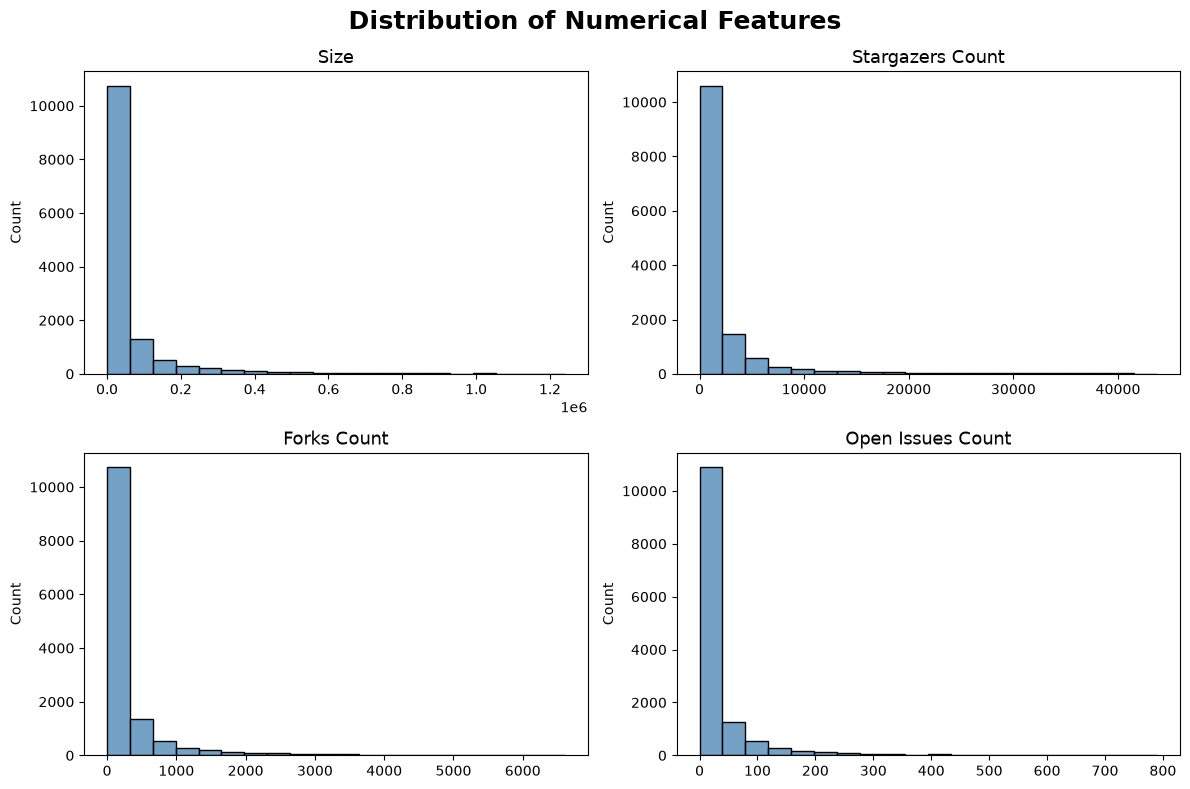

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

fig.suptitle(
    "Distribution of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plot_numerical_feature(df, "size", ax=axes[0, 0])
plot_numerical_feature(df, "stargazers_count", ax=axes[0, 1])
plot_numerical_feature(df, "forks_count", ax=axes[1, 0])
plot_numerical_feature(df, "open_issues_count", ax=axes[1, 1])

plt.tight_layout()
plt.show()

All numerical features exhibit highly right-skewed distributions. Most repositories have relatively low values, whereas only a small fraction reach very large sizes, star counts, fork counts, or numbers of open issues. This long-tail pattern is characteristic of GitHub repositories.

In [10]:
def outlier_summary(df, columns):
    summary = []

    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

        summary.append({
            "Feature": col,
            "Outliers": n_outliers,
            "Percentage": round(100 * n_outliers / len(df), 2)
        })

    return pd.DataFrame(summary)

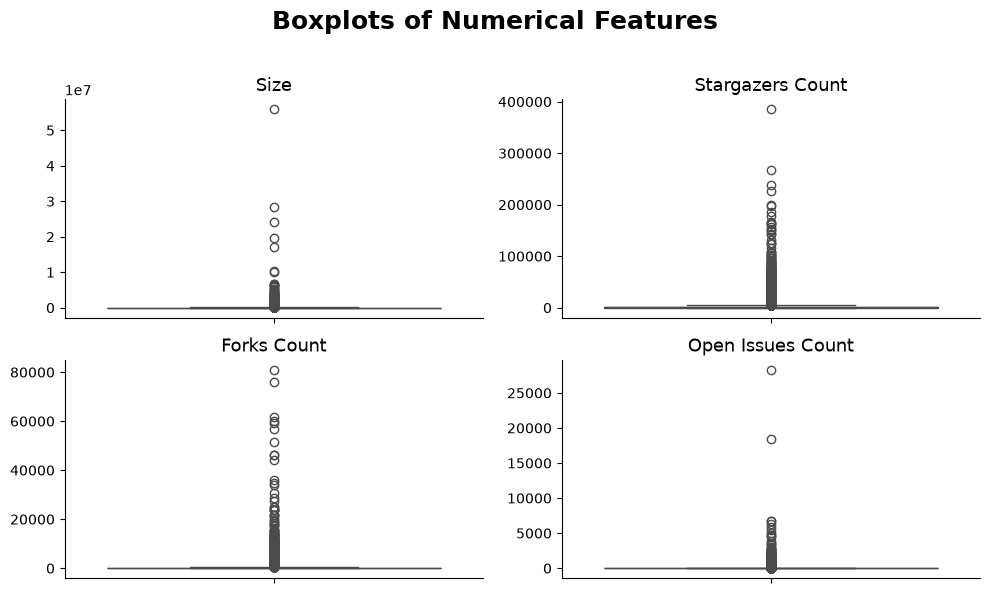

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

plot_boxplot(df, "size", axes[0, 0])
plot_boxplot(df, "stargazers_count", axes[0, 1])
plot_boxplot(df, "forks_count", axes[1, 0])
plot_boxplot(df, "open_issues_count", axes[1, 1])

fig.suptitle(
    "Boxplots of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

sns.despine()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [12]:
outlier_summary(
    df,
    [
        "size",
        "stargazers_count",
        "forks_count",
        "open_issues_count"
    ]
)

,Feature,Outliers,Percentage
0,size,1750,13
1,stargazers_count,1658,12
2,forks_count,1717,12
3,open_issues_count,1788,13


Each numerical feature contains approximately 12–13% outliers based on the IQR method, confirming the highly right-skewed nature of GitHub repository metrics.

#### The histogram and boxplot analyses indicate that all numerical features exhibit highly right-skewed distributions with a considerable number of outliers. Approximately 12–13% of observations were identified as outliers using the IQR method. This suggests that while most repositories remain relatively small and receive limited community engagement, a small number of projects account for exceptionally large sizes, high star counts, numerous forks, and many open issues.

### 3.2 Binary Variables Analysis

#### 3.2.1 "Owner type"

In [13]:
describe_column_distribution(
    df, 
    'owner.type', 
    title="Column 'owner.type' contains the following values:"
)

### Column 'owner.type' contains the following values:
Number of unique values: **2**

- **User**: 8050 (58.15%)
- **Organization**: 5794 (41.85%)


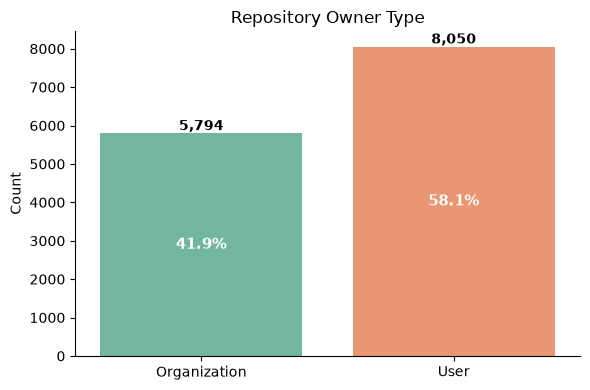

In [14]:
plot_binary_feature(df, "owner.type", "Repository Owner Type")

#### 3.2.2 "archived"

In [15]:
describe_column_distribution(
    df, 
    'archived', 
    title="Column 'archived' contains the following values:"
)

### Column 'archived' contains the following values:
Number of unique values: **2**

- **False**: 13231 (95.57%)
- **True**: 613 (4.43%)


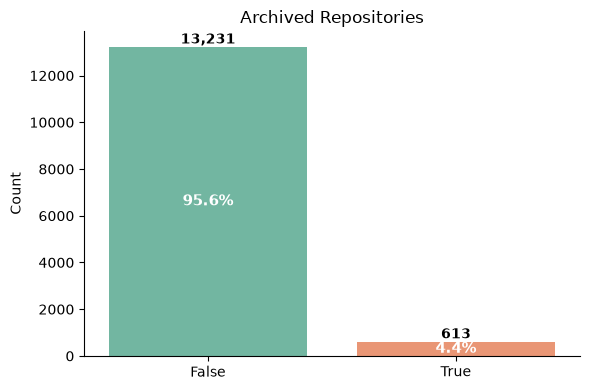

In [16]:
plot_binary_feature(df, "archived", "Archived Repositories")

#### 3.2.3 "has_issues"

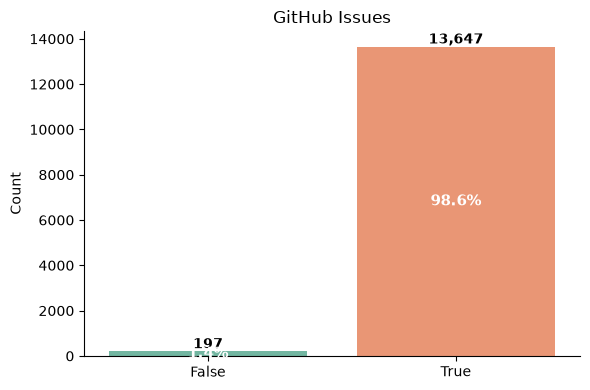

In [17]:
plot_binary_feature(df, "has_issues", "GitHub Issues")

In [18]:
describe_column_distribution(
    df, 
    'has_issues', 
    title="Column 'has_issues' contains the following values:"
)

### Column 'has_issues' contains the following values:
Number of unique values: **2**

- **True**: 13647 (98.58%)
- **False**: 197 (1.42%)


#### 3.2.4 "has_wiki"

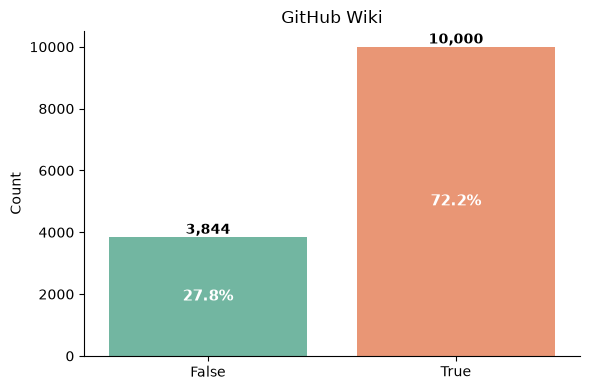

In [19]:
plot_binary_feature(df, "has_wiki", "GitHub Wiki")

In [20]:
describe_column_distribution(
    df, 
    'has_wiki', 
    title="Column 'has_wiki' contains the following values:"
)

### Column 'has_wiki' contains the following values:
Number of unique values: **2**

- **True**: 10000 (72.23%)
- **False**: 3844 (27.77%)


#### 3.2.5 "has_pages"

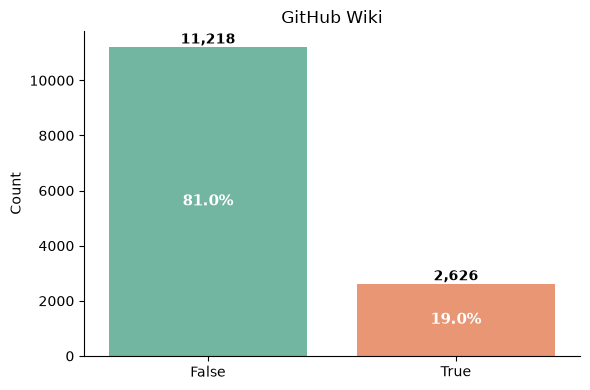

In [21]:
plot_binary_feature(df, "has_pages", "GitHub Wiki")


In [22]:
describe_column_distribution(
    df, 
    'has_pages', 
    title="Column 'has_pages' contains the following values:"
)

### Column 'has_pages' contains the following values:
Number of unique values: **2**

- **False**: 11218 (81.03%)
- **True**: 2626 (18.97%)


#### 3.2.6 "has_pages"

In [23]:
describe_column_distribution(
    df, 
    'has_discussions', 
    title="Column 'has_discussions' contains the following values:"
)

### Column 'has_discussions' contains the following values:
Number of unique values: **2**

- **False**: 10114 (73.06%)
- **True**: 3730 (26.94%)


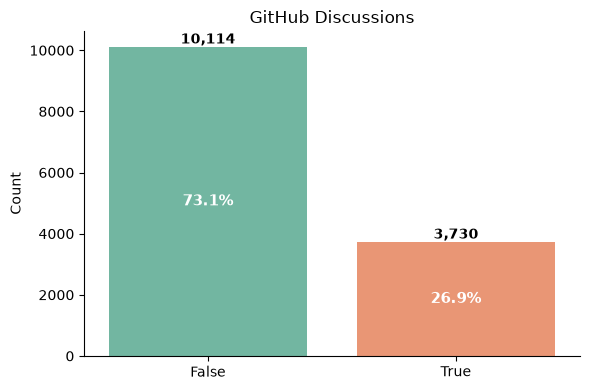

In [24]:
plot_binary_feature(df, "has_discussions", "GitHub Discussions")

## STEP 4. Most 10 Popular Programming Languages

### Repositories with an **Unknown** language were excluded from this analysis, as they do not provide meaningful information about programming language usage and could distort the results.

In [25]:
top_languages = (
    df.loc[df["language"] != "Unknown", "language"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_languages.columns = ["language", "count"]

top_languages["percentage"] = (
    top_languages["count"]
    / (df["language"] != "Unknown").sum()
    * 100
).round(2)

top_languages

,language,count,percentage
0,Python,6731,53
1,TypeScript,1578,13
2,Jupyter Notebook,1166,9
3,JavaScript,546,4
4,Go,420,3
5,Rust,367,3
6,C++,358,3
7,Java,219,2
8,HTML,213,2
9,Shell,146,1


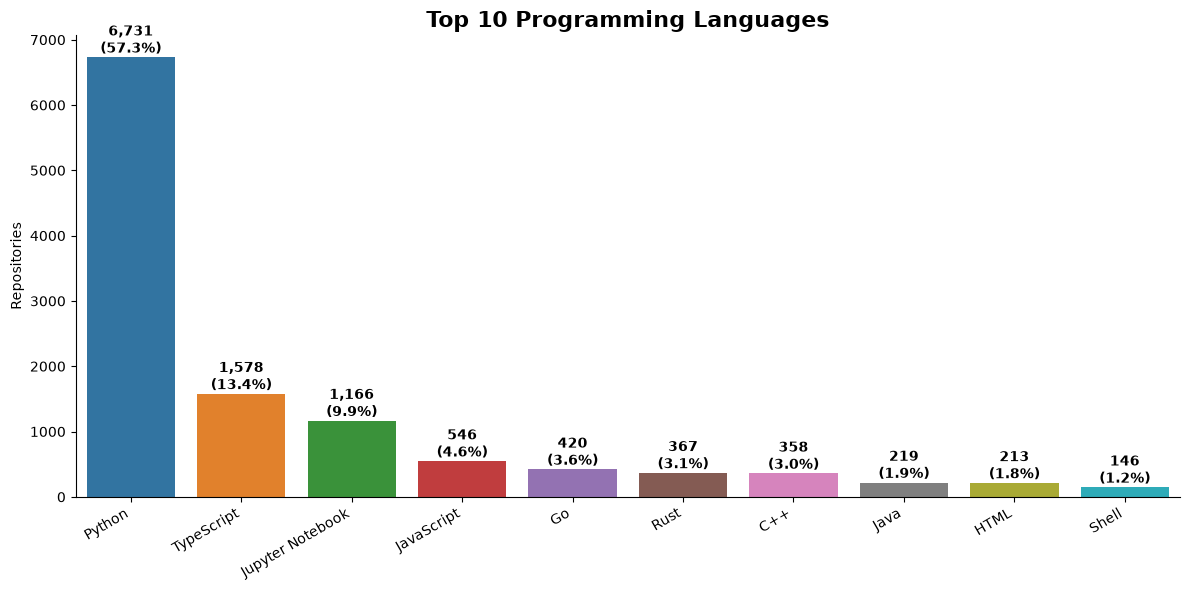

In [26]:
plot_top_languages(df)

In [27]:
plot_languages_over_time(df)

In [28]:
language_share = (
    df[df["language"] != "Unknown"]
    .groupby(["created_year", "language"])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum() * 100)
    .reset_index(name="percentage")
)

language_share.head()




ValueError: cannot insert created_year, already exists

In [ ]:
top10 = top_languages["language"]


fig = px.line(
    language_share[language_share["language"].isin(top10)],
    x="created_year",
    y="percentage",
    color="language",
    markers=True,
    title="Programming Language Share by Year in %",
)

fig.update_layout(
    width=1200,
    height=500,
    autosize=False,
    template="plotly_white",
    hovermode="closest",
    legend_title="Language",
    margin=dict(l=50, r=30, t=70, b=50),
)

fig.update_xaxes(
    tickmode="linear",
    dtick=1,
    tick0=df["created_year"].min()
)

fig.update_yaxes(title="Percentage (%)")

fig.update_traces(
    hovertemplate="<b>%{fullData.name}</b><br>"
                  "Year: %{x}<br>"
                  "Share: %{y:.2f}%<extra></extra>"
)

fig.show(config={
    "responsive": False,
    "displaylogo": False
})

## Conclusions

Python remained the dominant programming language throughout the analyzed period, consistently accounting for the largest number of newly created repositories.
TypeScript exhibited the strongest growth trend, especially in the most recent years, gradually increasing both its repository count and its percentage share among the most popular languages.
Most of the remaining programming languages showed relatively stable trends over time. Although their repository counts increased, their overall share changed only moderately compared with Python and TypeScript.
The recent decline in Python's repository count and percentage share should be interpreted with caution. While the observed trend may indicate changing development patterns, additional analyses are required to determine whether it reflects a genuine shift in language popularity or characteristics of the analyzed dataset.

## 5. Repository Popularity Analysis

### 5.1 Correlation Between Popularity Metrics

In [ ]:
popularity_features = [
    "stargazers_count",
    "forks_count",
    "open_issues_count",
    "size",
]

corr = df[popularity_features].corr(method="spearman")
corr

,stargazers_count,forks_count,open_issues_count,size
stargazers_count,1,1,1,0
forks_count,1,1,1,0
open_issues_count,1,1,1,0
size,0,0,0,1


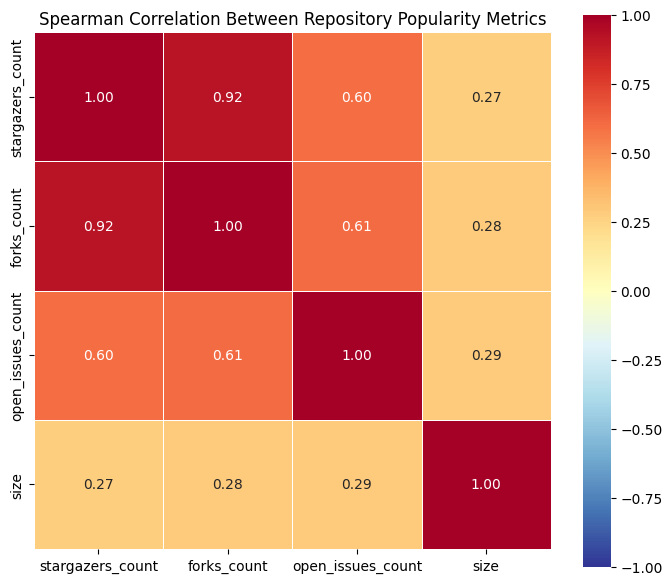

In [ ]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=.5,
)

plt.title("Spearman Correlation Between Repository Popularity Metrics")
plt.tight_layout()
plt.show()

#### Conclusions
- The strongest relationship was observed between the number of stars and forks (ρ = 0.92). This indicates that repositories receiving more stars also tend to be forked more frequently, suggesting these metrics capture similar aspects of repository popularity.
- A moderate positive correlation exists between open issues and both stars (ρ = 0.60) and forks (ρ = 0.61). More popular repositories generally have more open issues, which likely reflects higher community activity and ongoing development.
- Repository size exhibits only weak correlations with the remaining metrics (ρ ≈ 0.27–0.29). This suggests that larger repositories are not necessarily more popular or more actively maintained.
- Overall, repository popularity appears to be driven primarily by community engagement (stars and forks) rather than repository size.

### 5.2 Stars vs Forks

The scatter plot illustrates the relationship between the number of stars and forks for each repository. Each point represents a repository, while the color indicates its creation year. Both axes are displayed on a logarithmic scale to improve the visibility of repositories spanning several orders of magnitude.

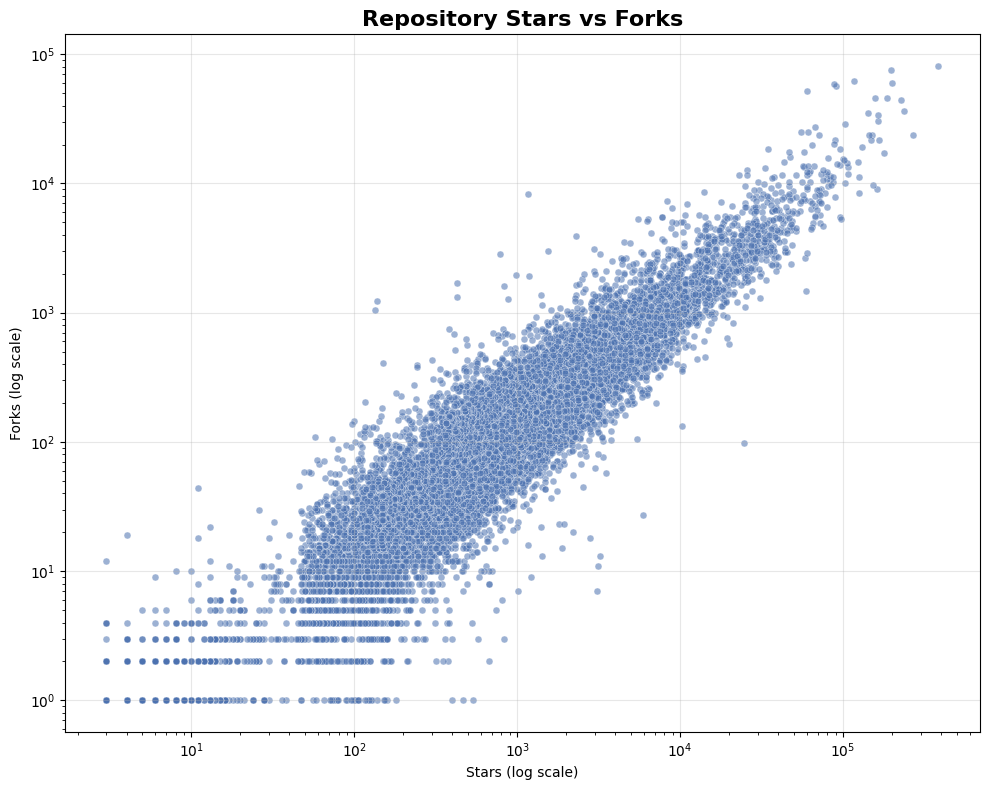

In [ ]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df,
    x="stargazers_count",
    y="forks_count",
    color="#4C72B0",
    alpha=0.55,
    s=25,
)

plt.xscale("log")
plt.yscale("log")

plt.title("Repository Stars vs Forks", fontsize=16, weight="bold")
plt.xlabel("Stars (log scale)")
plt.ylabel("Forks (log scale)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

The scatter plot illustrates the relationship between the number of stars and forks for each repository. Each point represents a repository, while the color indicates its creation year. Both axes are displayed on a logarithmic scale to improve the visibility of repositories spanning several orders of magnitude.

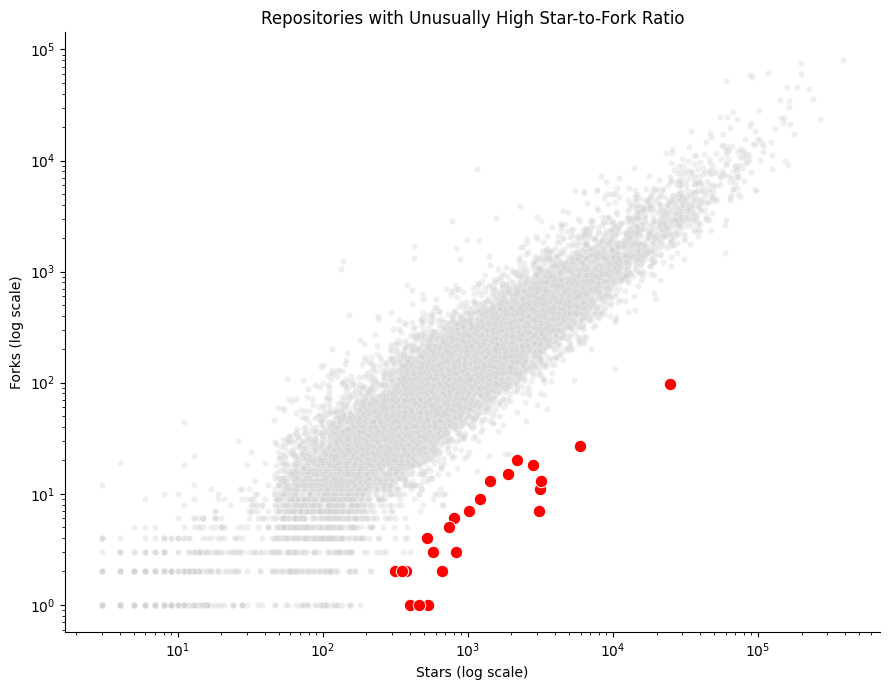

In [ ]:
df["star_fork_ratio"] = df["stargazers_count"] / (df["forks_count"] + 1)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df,
    x="stargazers_count",
    y="forks_count",
    color="lightgray",
    alpha=0.35,
    s=20,
)

outliers = df["star_fork_ratio"] > 100

sns.scatterplot(
    data=df[outliers],
    x="stargazers_count",
    y="forks_count",
    color="red",
    s=80,
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Stars (log scale)")
plt.ylabel("Forks (log scale)")
plt.title("Repositories with Unusually High Star-to-Fork Ratio")

sns.despine()
plt.tight_layout()
plt.show()

Repositories with an unusually high star-to-fork ratio are highlighted in red. These repositories deviate from the general trend and were further investigated to better understand the characteristics associated with this behavior.

In [ ]:
outliers = (
    df[df["stargazers_count"] / (df["forks_count"] + 1) > 100]
    [
        [
            "full_name",
            "owner.login",
            "owner.type",
            "language",
            "stargazers_count",
            "forks_count",
            "created_year"
        ]
    ]
    .sort_values("stargazers_count", ascending=False)
)

outliers.head(20)

,full_name,owner.login,owner.type,language,stargazers_count,forks_count,created_year
1123,Max-Eee/NeoPass,Max-Eee,User,JavaScript,24693,98,2024
7466,builderz-labs/mission-control,builderz-labs,Organization,TypeScript,5941,27,2026
6238,oxylabs/chatgpt-scraper,oxylabs,Organization,Java,3217,13,2025
1650,oxylabs/ai-crawler-py,oxylabs,Organization,Unknown,3124,11,2025
6242,dirk1983/deepseek,dirk1983,User,JavaScript,3108,7,2023
227,wenge-research/YAYI2,wenge-research,User,Python,2800,18,2023
6268,DanOps-1/Gpt-Agreement-Payment,DanOps-1,User,Python,2187,20,2026
2640,alan-ai/alan-sdk-ios,alan-ai,Organization,Objective-C,1883,15,2019
6810,Prismer-AI/PrismerCloud,Prismer-AI,Organization,TypeScript,1415,13,2026
7642,jieyefriic/rp-engine,jieyefriic,User,Rust,1223,9,2026


The table below presents the most extreme repositories identified in the outlier analysis. It includes additional metadata to help explain why these repositories received substantially more stars than forks.

#### Conclusons

The analysis confirms a strong positive relationship between the number of stars and forks, indicating that both metrics capture a similar aspect of repository popularity. However, the outlier analysis revealed a distinct group of repositories with exceptionally high star-to-fork ratios. Inspection of these repositories showed that many are recent projects (primarily created between 2023 and 2026), including AI-related applications, browser extensions, developer tools, and curated resource collections. Unlike traditional open-source projects, these repositories are primarily intended for consumption rather than modification. Consequently, while stars mainly reflect community interest and visibility, forks are more closely associated with collaborative development and code reuse.

## 6. Repository Ownership Analysis

### 6.1 Repository Popularity by Owner Type

In [ ]:
owner_counts = (
    df["owner.type"]
    .value_counts()
    .reset_index()
)

owner_counts.columns = ["owner_type", "repositories"]

owner_counts

,owner_type,repositories
0,User,8050
1,Organization,5794


In [ ]:
owner_stats = (
    df.groupby("owner.type")
    .agg(
        repositories=("owner.type", "size"),
        median_stars=("stargazers_count", "median"),
        median_forks=("forks_count", "median"),
        median_open_issues=("open_issues_count", "median"),
        median_size=("size", "median"),
    )
    .round(2)
)

owner_stats

,repositories,median_stars,median_forks,median_open_issues,median_size
owner.type,,,,,
Organization,5794,878,118,17,18830
User,8050,500,76,5,6017


In [ ]:
def plot_owner_popularity(owner_stats, figsize=(6, 5), palette="Set2"):
    """
    Plot median stars and forks by owner type.
    """

    plot_df = (
        owner_stats.reset_index()
        .melt(
            id_vars="owner.type",
            value_vars=["median_stars", "median_forks"],
            var_name="Metric",
            value_name="Median",
        )
    )

    plot_df["Metric"] = plot_df["Metric"].replace({
        "median_stars": "Stars",
        "median_forks": "Forks",
    })

    plot_df["Percentage"] = (
        plot_df.groupby("Metric")["Median"]
        .transform(lambda x: x / x.sum() * 100)
    )

    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=plot_df,
        x="owner.type",
        y="Median",
        hue="Metric",
        palette=palette,
    )

    # wartości nad słupkami
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.0f",
            fontsize=10,
            fontweight="bold",
            padding=3,
        )

    # procenty wewnątrz słupków
    for patch, (_, row) in zip(ax.patches, plot_df.iterrows()):
        ax.annotate(
            f"{row['Percentage']:.1f}%",
            (
                patch.get_x() + patch.get_width() / 2,
                patch.get_height() / 2,
            ),
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="white",
        )

    plt.title("Median Repository Popularity by Owner Type")
    plt.xlabel("")
    plt.ylabel("Median Count")

    sns.despine()
    plt.tight_layout()
    plt.show()

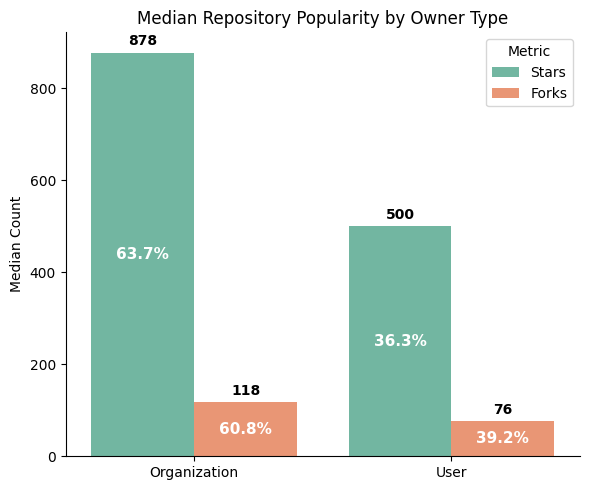

In [ ]:
plot_owner_popularity(owner_stats)

#### Conclusions

Repositories owned by organizations consistently outperform user-owned repositories across both popularity metrics. Although individual users publish more repositories overall, organization-owned repositories achieve substantially higher median numbers of stars and forks. Combined with their larger median repository size and higher number of open issues, this suggests that organizational repositories tend to be larger, more actively maintained, and attract greater community engagement.

### 6.2 Programming Language Distribution by Owner Type

In [ ]:
top_org_languages = (
    df[
        (df["owner.type"] == "Organization")
        & (df["language"] != "Unknown")
    ]["language"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_org_languages.columns = ["language", "count"]

top_org_languages["percentage"] = (
    top_org_languages["count"]
    / top_org_languages["count"].sum()
    * 100
).round(2)

top_org_languages

,language,count,percentage
0,Python,2916,57
1,TypeScript,819,16
2,Jupyter Notebook,389,8
3,Go,227,4
4,C++,214,4
5,Rust,194,4
6,JavaScript,170,3
7,Java,113,2
8,C#,58,1
9,HTML,53,1


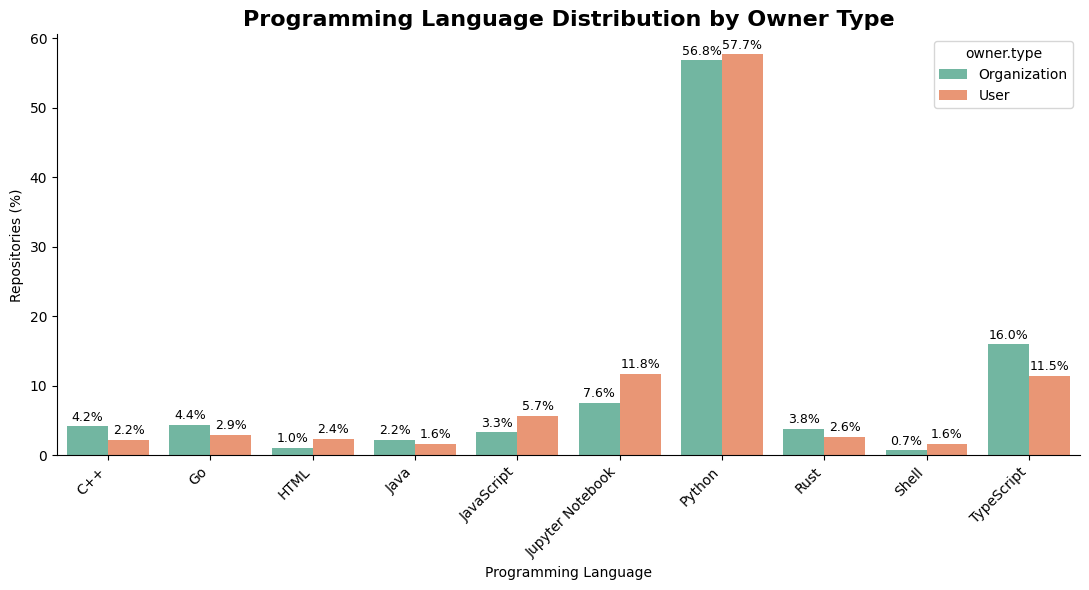

In [ ]:
github_colors = {
    "Python": "#3572A5",
    "TypeScript": "#3178C6",
    "JavaScript": "#F1E05A",
    "Java": "#B07219",
    "Go": "#00ADD8",
    "Rust": "#DEA584",
    "C++": "#F34B7D",
    "C": "#555555",
    "C#": "#178600",
    "PHP": "#4F5D95",
    "Ruby": "#701516",
    "Swift": "#F05138",
    "Kotlin": "#A97BFF",
    "Dart": "#00B4AB",
    "Scala": "#C22D40",
    "R": "#198CE7",
    "Jupyter Notebook": "#DA5B0B",
    "HTML": "#E34C26",
    "CSS": "#563D7C",
    "Shell": "#89E051",
}

# Top 10 languages in the whole dataset (without Unknown)
top10_languages = (
    df.loc[df["language"] != "Unknown", "language"]
    .value_counts()
    .head(10)
    .index
)

plot_df = (
    df[
        (df["language"].isin(top10_languages))
        & (df["language"] != "Unknown")
    ]
    .groupby(["language", "owner.type"])
    .size()
    .reset_index(name="count")
)

# Percentage within each owner type
plot_df["percentage"] = (
    plot_df.groupby("owner.type")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=plot_df,
    x="language",
    y="percentage",
    hue="owner.type",
    palette="Set2",
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=9,
        padding=2,
    )

plt.title(
    "Programming Language Distribution by Owner Type",
    fontsize=16,
    weight="bold",
)
plt.xlabel("Programming Language")
plt.ylabel("Repositories (%)")
plt.xticks(rotation=45, ha="right")

sns.despine()
plt.tight_layout()
plt.show()

#### Conclusions

Despite the differences in repository popularity between organizations and individual users, both groups exhibit remarkably similar programming language preferences. Python remains the dominant language in both cases, accounting for approximately 57% of repositories. The largest differences are observed for TypeScript, which is more common among organizations (16.0% vs. 11.5%), and Jupyter Notebook and JavaScript, which are relatively more common in user-owned repositories. Overall, repository ownership appears to have only a limited influence on programming language choice.

In [ ]:
licensed = df["license.name"].notna().sum()
unlicensed = df["license.name"].isna().sum()

print(f"Licensed: {licensed:,}")
print(f"No license: {unlicensed:,}")
print(f"{licensed / len(df) * 100:.1f}% licensed")

Licensed: 13,844
No license: 0
100.0% licensed


## STEP 7. Repository Features

### 7.1 Repository Discussions
Do repositories with Discussions enabled attract greater community engagement?

In [ ]:
discussion_stats = (
    df.groupby("has_discussions")
    .agg(
        repositories=("has_discussions", "size"),
        median_stars=("stargazers_count", "median"),
        median_forks=("forks_count", "median"),
        median_open_issues=("open_issues_count", "median"),
    )
    .round(2)
)

discussion_stats

,repositories,median_stars,median_forks,median_open_issues
has_discussions,,,,
False,10114,509,75,6
True,3730,1229,150,20


In [ ]:
def plot_discussion_popularity(discussion_stats, figsize=(6, 5), palette="Set2"):
    plot_df = (
        discussion_stats.reset_index()
        .melt(
            id_vars="has_discussions",
            value_vars=["median_stars", "median_forks"],
            var_name="Metric",
            value_name="Median",
        )
    )

    plot_df["Metric"] = plot_df["Metric"].replace({
        "median_stars": "Stars",
        "median_forks": "Forks",
    })

    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=plot_df,
        x="has_discussions",
        y="Median",
        hue="Metric",
        palette=palette,
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.0f",
            fontsize=10,
            fontweight="bold",
            padding=3,
        )

    plt.title("Repository Popularity by Discussions Availability")
    plt.xlabel("Discussions Enabled")
    plt.ylabel("Median Count")

    sns.despine()
    plt.tight_layout()
    plt.show()

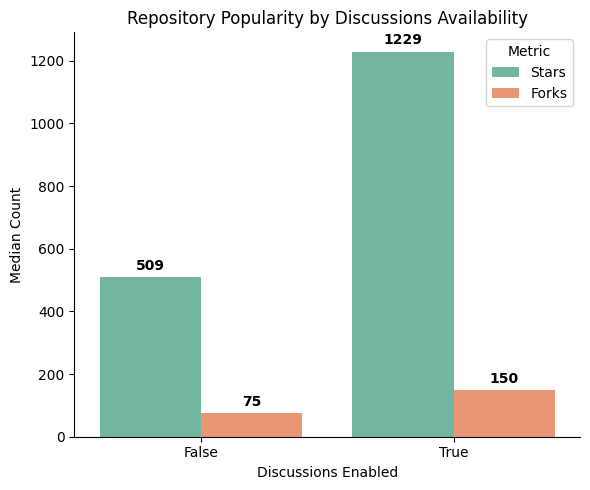

In [ ]:
plot_discussion_popularity(discussion_stats)

1. What does the data show?

Repositories with GitHub Discussions enabled demonstrate substantially higher levels of community engagement than repositories without this feature. The median repository with Discussions has 1,229 stars compared to 509 for repositories without Discussions, while the median number of forks is twice as high (150 vs. 75). Repositories with Discussions also report more than three times as many open issues (20 vs. 6).

2. Interpretation.

These findings suggest that GitHub Discussions are typically associated with larger, more active projects that attract stronger community participation and require additional communication channels beyond issue tracking.

3. Limitation of analysis.

However, this relationship should not be interpreted as causal. The results do not demonstrate that enabling Discussions increases repository popularity; rather, highly popular repositories may simply be more likely to adopt Discussions as their communities grow.

## 8. Repository Licensing

### 8.1 Most 10 Common Open-Source Licenses

In [ ]:
license_counts = (
    df[df["license.name"].notna()]
    .groupby("license.name")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="repositories")
)

license_counts.head(10)

,license.name,repositories
0,MIT License,5646
1,Apache License 2.0,3260
2,No license,2193
3,Other,1274
4,GNU General Public License v3.0,525
5,GNU Affero General Public License v3.0,332
6,"BSD 3-Clause ""New"" or ""Revised"" License",187
7,Creative Commons Zero v1.0 Universal,112
8,MIT No Attribution,45
9,"BSD 2-Clause ""Simplified"" License",43


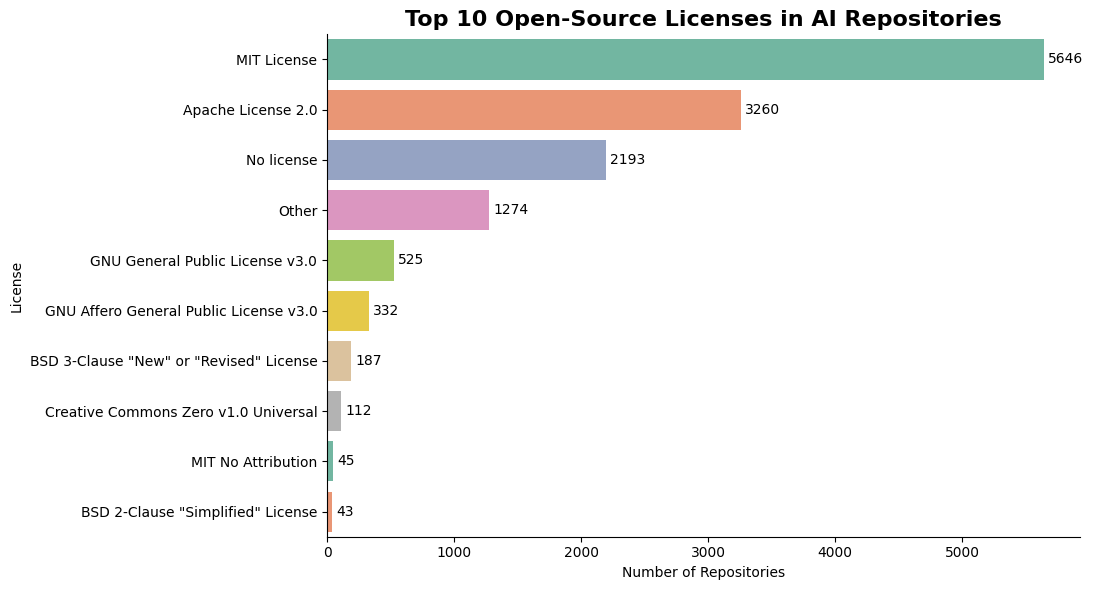

In [ ]:
top10_licenses = license_counts.head(10)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=top10_licenses,
    x="repositories",
    y="license.name",
    hue="license.name",
    palette="Set2",
    legend=False,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=10,
        padding=3,
    )

plt.title(
    "Top 10 Open-Source Licenses in AI Repositories",
    fontsize=16,
    weight="bold",
)
plt.xlabel("Number of Repositories")
plt.ylabel("License")

sns.despine()
plt.tight_layout()
plt.show()

### 8.2 Licene vs popularyty
Do different open-source licenses correlate with repository popularity?

In [ ]:
licenses = [
    "MIT License",
    "Apache License 2.0",
    "GNU General Public License v3.0",
    "GNU Affero General Public License v3.0",
    'BSD 3-Clause "New" or "Revised" License',
    "Creative Commons Zero v1.0 Universal",
]

license_popularity = (
    df[df["license.name"].isin(licenses)]
    .groupby("license.name")
    .agg(
        repositories=("license.name", "size"),
        median_stars=("stargazers_count", "median"),
        median_forks=("forks_count", "median"),
        median_open_issues=("open_issues_count", "median"),
    )
    .round(0)
    .sort_values("median_stars", ascending=False)
)

license_popularity

,repositories,median_stars,median_forks,median_open_issues
license.name,,,,
"BSD 3-Clause ""New"" or ""Revised"" License",187,1038,162,24
GNU Affero General Public License v3.0,332,930,130,15
Apache License 2.0,3260,816,112,16
GNU General Public License v3.0,525,589,107,10
MIT License,5646,568,84,7
Creative Commons Zero v1.0 Universal,112,530,72,4


In [ ]:
plot_df = (
    license_popularity
    .reset_index()
    .melt(
        id_vars="license.name",
        value_vars=["median_stars", "median_forks"],
        var_name="Metric",
        value_name="Median",
    )
)

plot_df["Metric"] = plot_df["Metric"].replace({
    "median_stars": "Stars",
    "median_forks": "Forks",
})

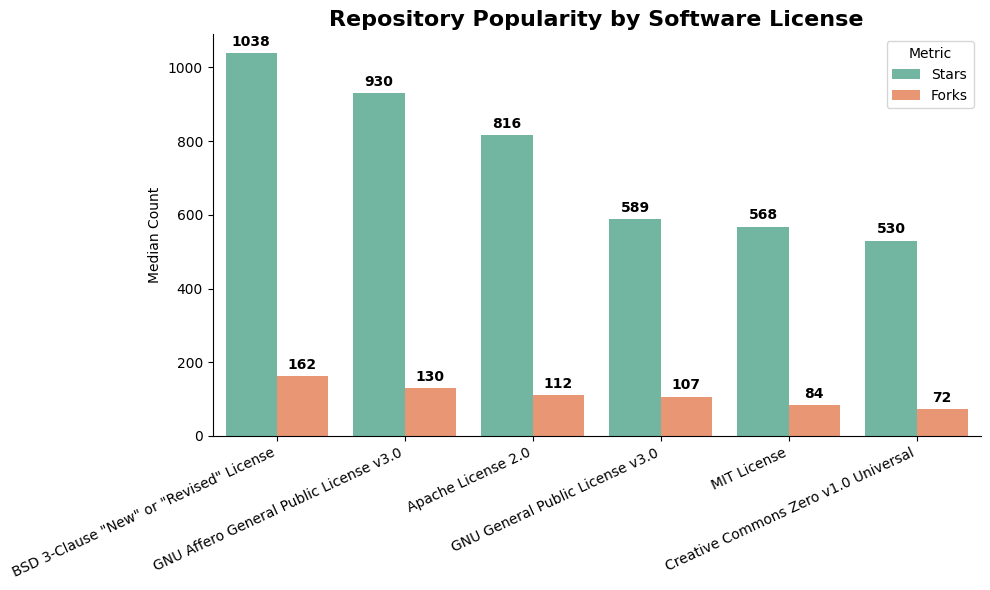

In [ ]:
def plot_license_popularity(plot_df, figsize=(10, 6), palette="Set2"):
    """
    Plot median stars and forks by software license.

    Parameters
    ----------
    plot_df : pd.DataFrame
        Melted DataFrame containing:
        - license.name
        - Metric
        - Median
    figsize : tuple
        Figure size.
    palette : str, list or dict
        Seaborn palette.
    """

    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=plot_df,
        x="license.name",
        y="Median",
        hue="Metric",
        palette=palette,
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.0f",
            fontsize=10,
            fontweight="bold",
            padding=3,
        )

    plt.title(
        "Repository Popularity by Software License",
        fontsize=16,
        weight="bold",
    )

    plt.xlabel("")
    plt.ylabel("Median Count")

    plt.xticks(rotation=25, ha="right")

    sns.despine()
    plt.tight_layout()
    plt.show()

plot_license_popularity(plot_df)

### Conclusions

Repository popularity differs across software licenses. Repositories distributed under BSD 3-Clause and Apache 2.0 exhibit higher median numbers of stars and forks than those using MIT or GPL licenses. However, these results indicate an association rather than a causal relationship and should be interpreted with caution, as the number of repositories varies substantially between licenses.

### 8.3 License Distribution Across Programming Languages


In [ ]:
top_languages = (
    df.loc[df["language"] != "Unknown", "language"]
    .dropna()
    .value_counts()
    .head(10)
    .index
)

top_licenses = (
    df.loc[
        ~df["license.name"].isin(["No license", "Other"]),
        "license.name",
    ]
    .dropna()
    .value_counts()
    .head(5)
    .index
)

license_language = (
    df[
        df["language"].isin(top_languages)
        & df["license.name"].isin(top_licenses)
    ]
    .groupby(["language", "license.name"])
    .size()
    .reset_index(name="count")
)

# Percentage within each language
license_language["percentage"] = (
    license_language.groupby("language")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

heatmap_df = (
    license_language
    .pivot(
        index="license.name",
        columns="language",
        values="percentage",
    )
    .fillna(0)
    .round(1)
)

heatmap_df

language,C++,Go,HTML,Java,JavaScript,Jupyter Notebook,Python,Rust,Shell,TypeScript
license.name,,,,,,,,,,
Apache License 2.0,42,44,18,67,16,30,37,45,23,24
"BSD 3-Clause ""New"" or ""Revised"" License",6,2,2,0,0,2,2,1,1,0
GNU Affero General Public License v3.0,2,7,2,2,7,1,2,5,0,8
GNU General Public License v3.0,9,4,3,7,7,4,5,4,9,4
MIT License,41,43,76,24,70,62,54,46,67,64


In [ ]:
heatmap_df_license = (
    license_language
    .pivot(
        index="license.name",
        columns="language",
        values="count",
    )
    .fillna(0)
)

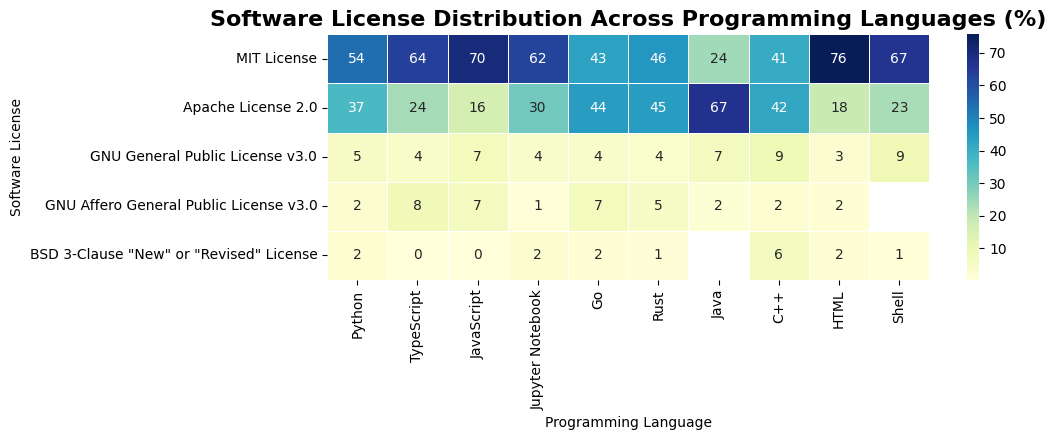

In [ ]:
license_order = [
    "MIT License",
    "Apache License 2.0",
    "GNU General Public License v3.0",
    "GNU Affero General Public License v3.0",
    'BSD 3-Clause "New" or "Revised" License',
]

language_order = [
    "Python",
    "TypeScript",
    "JavaScript",
    "Jupyter Notebook",
    "Go",
    "Rust",
    "Java",
    "C++",
    "HTML",
    "Shell",
]

heatmap_df_license = (
    license_language
    .pivot(
        index="license.name",
        columns="language",
        values="percentage",
    )
    .reindex(index=license_order)
    .reindex(columns=language_order)
    .round(1)
)

plt.figure(figsize=(11, 4.5))

sns.heatmap(
    heatmap_df_license,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
)

plt.title(
    "Software License Distribution Across Programming Languages (%)",
    fontsize=16,
    weight="bold",
)

plt.xlabel("Programming Language")
plt.ylabel("Software License")

plt.tight_layout()
plt.show()

The analysis indicates that programming language ecosystems exhibit distinct licensing preferences. While MIT License is the dominant choice for most languages, Java repositories show a stronger preference for Apache License 2.0. Despite these differences, permissive licenses consistently dominate across the AI ecosystem, whereas copyleft licenses remain relatively uncommon.

## STEP 9 AI Topics

### STEP 9.1 AI Topics Across Programming Languages

In [ ]:
AI_TOPICS = [
    "artificial-intelligence",
    "ai",
    "machine-learning",
    "deep-learning",
    "llm",
    "large-language-models",
    "generative-ai",
    "gpt",
    "chatgpt",
    "rag",
    "mcp",
    "agents",
    "agentic-ai",
    "agentic-workflow",
    "nlp",
    "natural-language-processing",
    "computer-vision",
    "reinforcement-learning",
    "pytorch",
    "tensorflow",
]

TOP_LANGUAGES = [
    "Python",
    "TypeScript",
    "Jupyter Notebook",
    "C++",
    "Rust",
    "JavaScript",
    "Java",
    "Go",
    "HTML",
    "Shell",
]

topics_df = df[["id", "language", "topics"]].copy()

topics_df["topics"] = topics_df["topics"].apply(ast.literal_eval)

topics_df = topics_df.explode("topics")

topics_df = topics_df[
    topics_df["topics"].isin(AI_TOPICS)
]

topics_df = topics_df[
    topics_df["language"].isin(TOP_LANGUAGES)
]

language_totals = (
    topics_df
    .groupby("language")["id"]
    .nunique()
)

language_topic = (
    topics_df
    .groupby(["language", "topics"])["id"]
    .nunique()
    .reset_index(name="repo_count")
)

language_topic["percentage"] = (
    language_topic["repo_count"]
    / language_topic["language"].map(language_totals)
    * 100
)

interesting_topics = [
    "agentic-ai",
    "agents",
    "chatgpt",
    "computer-vision",
    "deep-learning",
    "llm",
    "machine-learning",
    "mcp",
    "pytorch",
    "rag",
]

plot_df = (
    language_topic
    .pivot(
        index="topics",
        columns="language",
        values="percentage",
    )
    .fillna(0)
    .reindex(interesting_topics)
    .fillna(0)
)

In [ ]:
display(plot_df)

language,C++,Go,HTML,Java,JavaScript,Jupyter Notebook,Python,Rust,Shell,TypeScript
topics,,,,,,,,,,
agentic-ai,1,16,15,7,12,3,8,17,20,16
agents,1,20,11,6,9,4,7,15,16,16
chatgpt,2,13,12,12,18,5,6,6,8,17
computer-vision,23,1,6,4,3,12,9,2,0,1
deep-learning,27,3,11,7,8,36,21,3,6,1
llm,10,28,23,22,20,14,20,34,23,27
machine-learning,27,9,17,14,12,33,17,9,9,3
mcp,3,26,8,17,16,1,7,23,10,25
pytorch,11,2,3,3,2,22,17,1,1,0


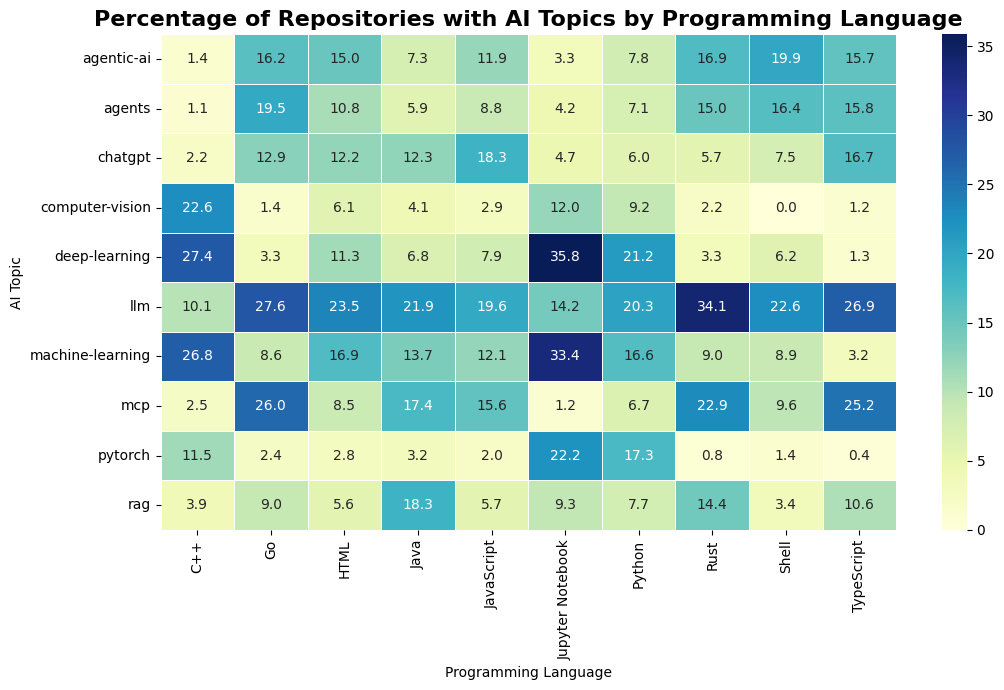

In [ ]:
plt.figure(figsize=(11, 7))

sns.heatmap(
    plot_df,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
)

plt.title(
    "Percentage of Repositories with AI Topics by Programming Language",
    fontsize=16,
    weight="bold",
)

plt.xlabel("Programming Language")
plt.ylabel("AI Topic")

plt.tight_layout()
plt.show()

### Description

The heatmap illustrates the percentage of repositories in each of the ten most common programming languages that are tagged with selected AI-related topics. This allows direct comparison of how frequently specific AI topics appear within repositories of each programming language, regardless of the total number of repositories.

### Findings

Overall, the combined results suggest that different programming languages are associated with different areas of the AI ecosystem. While Python and Jupyter Notebook remain closely linked to traditional machine learning workflows, newer languages such as TypeScript and Go appear more frequently in repositories focused on LLM-based applications and modern AI tooling.

## Key Insights from the Programming Language Analysis

- Python remained the dominant programming language throughout the analyzed period, consistently accounting for the largest number of AI repositories. The topic analysis further shows that Python repositories are most frequently associated with Deep Learning, Machine Learning, LLMs, and PyTorch, reinforcing its central role in AI research and model development.

- Jupyter Notebook serves as a complementary environment for AI experimentation and research. Although the number of newly created notebook repositories has decreased in recent years, they continue to exhibit high proportions of Deep Learning, Machine Learning, and PyTorch topics, indicating that notebooks remain widely used for experimentation, prototyping, and educational purposes.

- TypeScript has experienced the most rapid growth since 2023 and shows strong associations with LLMs, Agents, ChatGPT, and MCP. Compared with Python, its repositories place less emphasis on traditional Machine Learning topics, suggesting an increasing adoption of TypeScript for AI-powered applications, agent-based systems, and large language model integrations.

- C++ remains consistently associated with Computer Vision, exhibiting the highest proportion of repositories tagged with this topic among the analyzed languages. It also maintains a noticeable presence in Deep Learning repositories, reflecting its continued importance in performance-oriented AI applications.
Rust has shown steady growth in recent years and is increasingly associated with LLMs, Agents, and MCP. These patterns suggest that Rust is becoming more prominent within modern AI tooling and infrastructure, particularly in projects where performance and reliability are important considerations.

## Summary

### The conducted exploratory data analysis addressed the proposed research questions and led to the following conclusions:

1. Which programming languages dominate the AI ecosystem, and how have their trends changed over time?
 - Python remained the dominant programming language throughout the analyzed period, while TypeScript exhibited the fastest growth in recent years. Most other languages showed relatively stable trends.

2. How are the key repository popularity metrics related to one another?
- Stars and forks exhibited the strongest positive relationship, while repository size showed only weak correlations with the remaining metrics. Overall, repository popularity was driven primarily by community engagement rather than repository size.

3. Do stars and forks measure the same aspect of repository popularity?
- Although strongly correlated, stars and forks capture slightly different aspects of popularity. Stars primarily reflect community interest and visibility, whereas forks better represent collaborative development and code reuse.

4. Do organization-owned repositories attract greater community engagement than user-owned repositories?
- Organization-owned repositories consistently achieved higher median numbers of stars, forks, and open issues, indicating greater community engagement and more active maintenance.

5. Do organizations and individual users prefer different programming languages?
- Both groups exhibited remarkably similar programming language preferences. Python dominated in both cases, while only minor differences were observed for TypeScript, JavaScript, and Jupyter Notebook.

6. Do repositories with GitHub Discussions enabled attract greater community engagement?
- Repositories with Discussions consistently showed higher levels of community engagement. However, this relationship should be interpreted as an association rather than evidence of causality.

7. Does repository popularity vary across different software licenses?
- Repository popularity differed across software licenses, with BSD 3-Clause and Apache 2.0 repositories generally achieving higher median popularity metrics than repositories using MIT or GPL licenses.

8. Which software licenses are most commonly used across different programming languages?
- MIT License was the dominant license across most programming languages, while Java repositories showed a stronger preference for Apache License 2.0. Overall, permissive licenses dominated the analyzed AI ecosystem.

9. Do repositories written in different programming languages exhibit different AI topic distributions?
- Distinct programming languages were associated with different AI topic profiles. Python remained strongly connected with traditional AI domains such as Deep Learning and Machine Learning, whereas TypeScript and Rust showed stronger associations with modern LLM-related technologies.

10. How Have AI Topics Changed Over Time?
- This research question could not be answered because the GitHub API provides only the current repository topics and does not retain the history of topic assignments.

Overall, the analysis demonstrates that the GitHub AI ecosystem combines long-established technologies with rapidly emerging trends. While Python continues to dominate traditional AI development, newer technologies and programming languages increasingly shape modern AI software engineering.

In [ ]:
Markdown('Thank you 🫠️')

Thank you 🫠️